In [9]:
# Configuration cell (run this first)
PLOT_CFG = {
    # Global font settings
    "font_family": "DejaVu Sans",
    "font_color": "#111111",
    "title_fontsize": 20,
    "axis_label_fontsize": 16,
    "tick_label_fontsize": 14,
    "bar_value_fontsize": 14,
    "panel_label_fontsize": 20,

    # Figure sizes
    "figsize_trend": (14, 10),
    "figsize_wordcloud": (16, 10),

    # Trend bar settings
    "bar_width": 0.55,
    "article_bar_color": "#1f77b4",
    "selected_bar_color": "#d62728",
    "bar_alpha": 0.9,
    "force_integer_y_ticks": True,
    "y_axis_max_pad_ratio": 0.12,
    "y_axis_min_pad": 1,
    "bar_value_offset_ratio": 0.015,

    # Marker label box (a, b)
    "panel_box_facecolor": "#ffffff",
    "panel_box_edgecolor": "#000000",
    "panel_box_alpha": 0.95,

    # Word cloud settings
    "wc_article_colormap": "viridis",
    "wc_selected_colormap": "plasma",
    "wc_background_color": "white",
}

print("Configuration loaded. Edit PLOT_CFG values here anytime before running plot cells.")

Configuration loaded. Edit PLOT_CFG values here anytime before running plot cells.


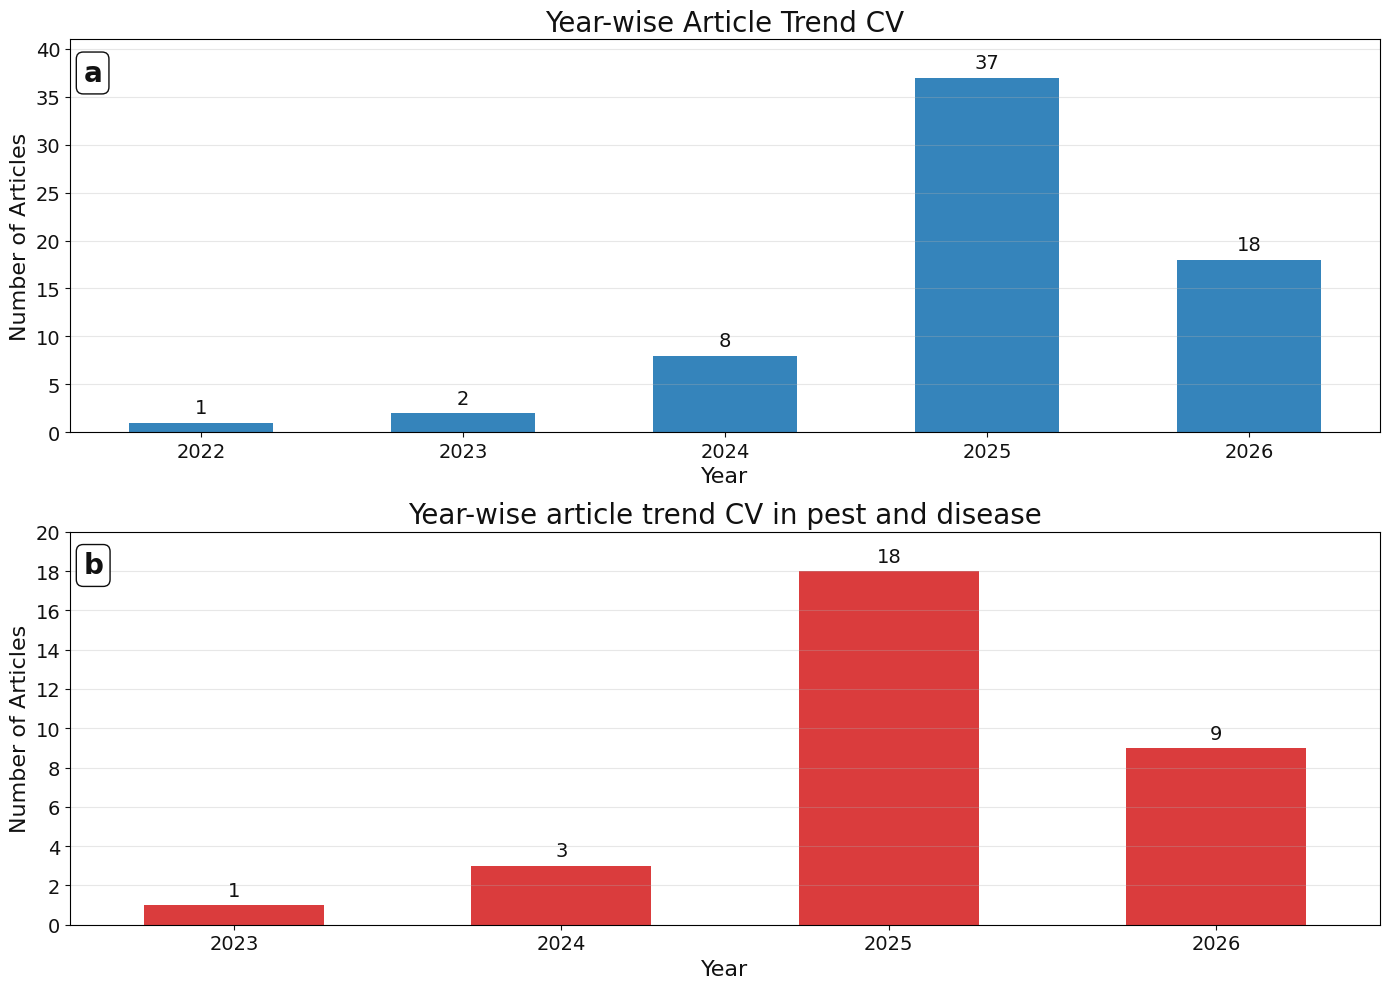

Saved: C:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\codes\year_wise_article_trends.png
Using year columns -> article: Year, selected: Year


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd

cfg = PLOT_CFG
plt.rcParams["font.family"] = cfg["font_family"]
plt.rcParams["text.color"] = cfg["font_color"]
plt.rcParams["axes.labelcolor"] = cfg["font_color"]
plt.rcParams["xtick.color"] = cfg["font_color"]
plt.rcParams["ytick.color"] = cfg["font_color"]

# --- File path ---
excel_path = Path(r"c:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\RAW\Main_database.xlsx")

# --- Helpers ---
def find_sheet_name(sheet_names, preferred):
    low_map = {s.lower().strip(): s for s in sheet_names}

    for name in preferred:
        if name.lower().strip() in low_map:
            return low_map[name.lower().strip()]

    for s in sheet_names:
        s_low = s.lower().strip()
        if any(name.lower().strip() in s_low for name in preferred):
            return s

    raise ValueError(f"Could not find sheet. Available sheets: {sheet_names}")


def detect_year_column(df):
    candidates = []
    for c in df.columns:
        c_low = str(c).lower()
        if "year" in c_low or "publication" in c_low or "pub" in c_low:
            candidates.append(c)

    if not candidates:
        raise ValueError(f"No year-like column found in columns: {list(df.columns)}")

    best_col = candidates[0]
    best_score = -1
    for c in candidates:
        s = pd.to_numeric(df[c], errors="coerce")
        score = s.notna().sum()
        if score > best_score:
            best_score = score
            best_col = c
    return best_col


def clean_year_series(series):
    s = series.astype(str).str.extract(r"(19\d{2}|20\d{2}|21\d{2})", expand=False)
    s = pd.to_numeric(s, errors="coerce").dropna().astype(int)
    s = s[(s >= 1900) & (s <= 2100)]
    return s


 # --- Read workbook and sheets ---
xls = pd.ExcelFile(excel_path)
article_sheet = find_sheet_name(xls.sheet_names, ["article"] )
selected_sheet = find_sheet_name(xls.sheet_names, ["selecetdd", "selected", "select"] )

article_df = pd.read_excel(excel_path, sheet_name=article_sheet)
selected_df = pd.read_excel(excel_path, sheet_name=selected_sheet)

# --- Detect year columns and aggregate ---
article_year_col = detect_year_column(article_df)
selected_year_col = detect_year_column(selected_df)

article_year_counts = clean_year_series(article_df[article_year_col]).value_counts().sort_index()
selected_year_counts = clean_year_series(selected_df[selected_year_col]).value_counts().sort_index()

# --- Plot (Image 1): Year-wise article trends as bar charts ---
fig, axes = plt.subplots(2, 1, figsize=cfg["figsize_trend"], sharex=False)
label_box = {
    "boxstyle": "round,pad=0.25",
    "facecolor": cfg["panel_box_facecolor"],
    "edgecolor": cfg["panel_box_edgecolor"],
    "alpha": cfg["panel_box_alpha"],
}

bars0 = axes[0].bar(
    article_year_counts.index,
    article_year_counts.values,
    width=cfg["bar_width"],
    color=cfg["article_bar_color"],
    alpha=cfg["bar_alpha"],
)
axes[0].set_title(f"Year-wise Article Trend CV", fontsize=cfg["title_fontsize"])
axes[0].set_xlabel("Year", fontsize=cfg["axis_label_fontsize"])
axes[0].set_ylabel("Number of Articles", fontsize=cfg["axis_label_fontsize"])
axes[0].grid(axis="y", alpha=0.3)
axes[0].text(
    0.01,
    0.95,
    "a",
    transform=axes[0].transAxes,
    fontsize=cfg["panel_label_fontsize"],
    fontweight="bold",
    va="top",
    bbox=label_box,
)
axes[0].set_xticks(article_year_counts.index.tolist())
axes[0].set_xlim(article_year_counts.index.min() - 0.5, article_year_counts.index.max() + 0.5)
axes[0].tick_params(axis="both", labelsize=cfg["tick_label_fontsize"])

max0 = int(article_year_counts.max()) if len(article_year_counts) else 0
y_pad0 = max(cfg["y_axis_min_pad"], int(round(max0 * cfg["y_axis_max_pad_ratio"])))
y_offset0 = max(0.2, max0 * cfg["bar_value_offset_ratio"])
axes[0].set_ylim(0, max0 + y_pad0)
if cfg.get("force_integer_y_ticks", True):
    axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
for bar in bars0:
    h = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        h + y_offset0,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=cfg["bar_value_fontsize"],
    )

bars1 = axes[1].bar(
    selected_year_counts.index,
    selected_year_counts.values,
    width=cfg["bar_width"],
    color=cfg["selected_bar_color"],
    alpha=cfg["bar_alpha"],
)
axes[1].set_title(f"Year-wise article trend CV in pest and disease", fontsize=cfg["title_fontsize"])
axes[1].set_xlabel("Year", fontsize=cfg["axis_label_fontsize"])
axes[1].set_ylabel("Number of Articles", fontsize=cfg["axis_label_fontsize"])
axes[1].grid(axis="y", alpha=0.3)
axes[1].text(
    0.01,
    0.95,
    "b",
    transform=axes[1].transAxes,
    fontsize=cfg["panel_label_fontsize"],
    fontweight="bold",
    va="top",
    bbox=label_box,
)
axes[1].set_xticks(selected_year_counts.index.tolist())
axes[1].set_xlim(selected_year_counts.index.min() - 0.5, selected_year_counts.index.max() + 0.5)
axes[1].tick_params(axis="both", labelsize=cfg["tick_label_fontsize"])

max1 = int(selected_year_counts.max()) if len(selected_year_counts) else 0
y_pad1 = max(cfg["y_axis_min_pad"], int(round(max1 * cfg["y_axis_max_pad_ratio"])))
y_offset1 = max(0.2, max1 * cfg["bar_value_offset_ratio"])
axes[1].set_ylim(0, max1 + y_pad1)
if cfg.get("force_integer_y_ticks", True):
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
for bar in bars1:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        h + y_offset1,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=cfg["bar_value_fontsize"],
    )

plt.tight_layout()
out1 = Path("year_wise_article_trends.png")
plt.savefig(out1, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out1.resolve()}")
print(f"Using year columns -> article: {article_year_col}, selected: {selected_year_col}")

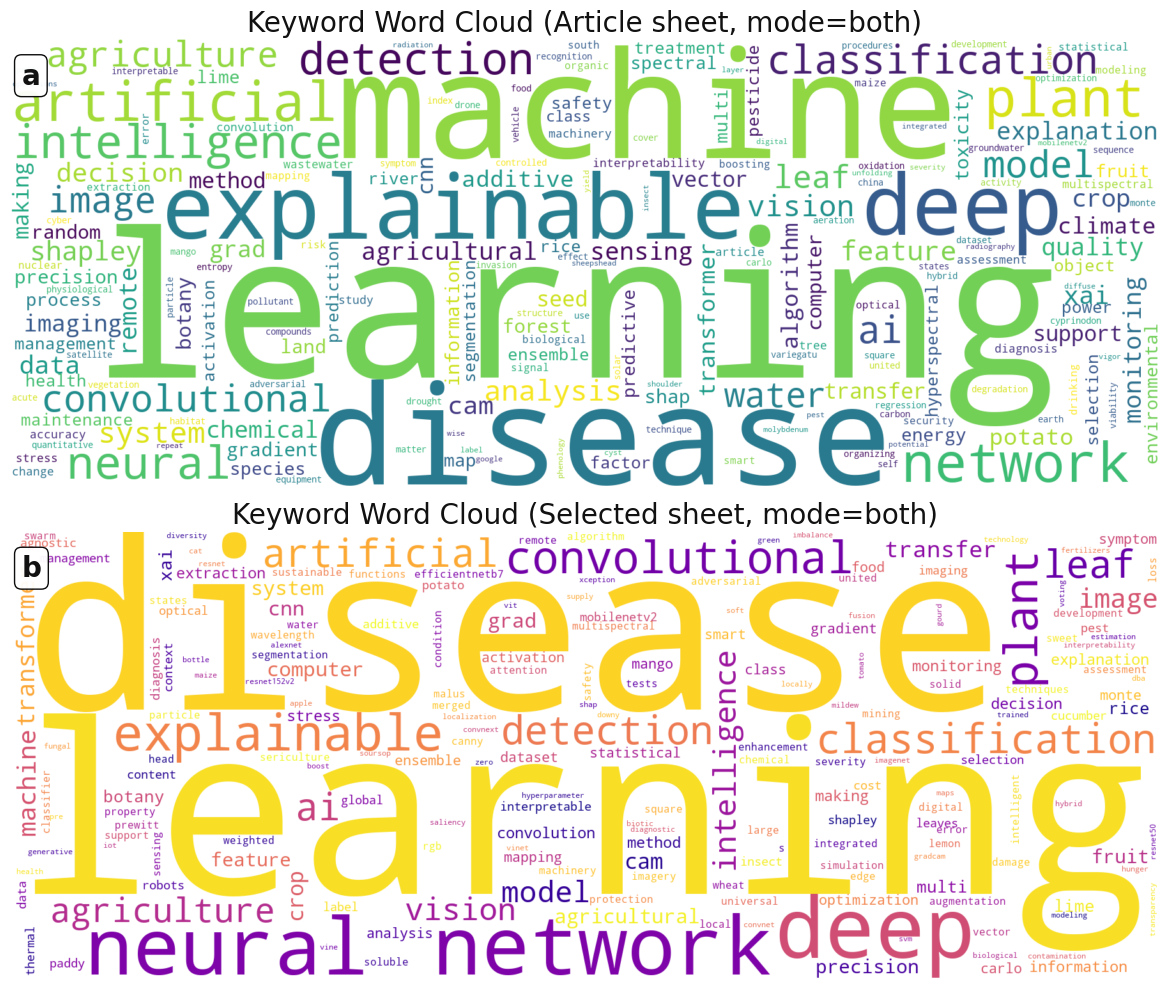

Saved: C:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\codes\keyword_wordclouds.png
Using keyword columns -> article: ['Author Keywords', 'Index Keywords'], selected: ['Author Keywords', 'Index Keywords']


In [11]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import STOPWORDS, WordCloud

cfg = PLOT_CFG
plt.rcParams["font.family"] = cfg["font_family"]
plt.rcParams["text.color"] = cfg["font_color"]
plt.rcParams["axes.labelcolor"] = cfg["font_color"]
plt.rcParams["xtick.color"] = cfg["font_color"]
plt.rcParams["ytick.color"] = cfg["font_color"]

# --- File path ---
excel_path = Path(r"c:\Users\kamalesh\OneDrive\Articles\Review Article\4. ExplainableAI\RAW\Main_database.xlsx")

# Choose keyword source: "author", "index", or "both"
KEYWORD_MODE = "both"

# --- Helpers ---
def find_sheet_name(sheet_names, preferred):
    low_map = {s.lower().strip(): s for s in sheet_names}

    for name in preferred:
        if name.lower().strip() in low_map:
            return low_map[name.lower().strip()]

    for s in sheet_names:
        s_low = s.lower().strip()
        if any(name.lower().strip() in s_low for name in preferred):
            return s

    raise ValueError(f"Could not find sheet. Available sheets: {sheet_names}")


def detect_keyword_columns(df):
    cols = []
    for c in df.columns:
        c_low = str(c).lower()
        if "keyword" in c_low:
            cols.append(c)

    if cols:
        return cols

    fallback_names = ["author keywords", "index keywords", "keywords plus"]
    for c in df.columns:
        c_low = str(c).lower().strip()
        if c_low in fallback_names:
            cols.append(c)

    if not cols:
        raise ValueError(f"No keyword-like columns found in columns: {list(df.columns)}")

    return cols


def choose_keyword_columns(df, mode):
    all_cols = detect_keyword_columns(df)
    author_cols = [c for c in all_cols if "author" in str(c).lower()]
    index_cols = [c for c in all_cols if "index" in str(c).lower()]

    mode = mode.lower().strip()
    if mode == "author":
        chosen = author_cols
    elif mode == "index":
        chosen = index_cols
    elif mode == "both":
        chosen = list(dict.fromkeys(author_cols + index_cols))
        if not chosen:
            chosen = all_cols
    else:
        raise ValueError("KEYWORD_MODE must be 'author', 'index', or 'both'.")

    if not chosen:
        raise ValueError(f"No columns found for KEYWORD_MODE='{mode}'. Available keyword columns: {all_cols}")

    return chosen


def extract_keyword_text(df, keyword_cols):
    text_parts = []
    for col in keyword_cols:
        series = df[col].dropna().astype(str)
        text_parts.extend(series.tolist())
    return " ; ".join(text_parts)


def normalize_for_wordcloud(text):
    tokens = re.split(r"[;,|\n\t]+", text)
    cleaned = []
    for t in tokens:
        t = re.sub(r"[^a-zA-Z0-9\-\s]", " ", t).strip().lower()
        t = re.sub(r"\s+", " ", t)
        if len(t) >= 3 and t not in STOPWORDS:
            cleaned.append(t)
    return " ".join(cleaned)


 # --- Read workbook and sheets ---
xls = pd.ExcelFile(excel_path)
article_sheet = find_sheet_name(xls.sheet_names, ["article"] )
selected_sheet = find_sheet_name(xls.sheet_names, ["selecetdd", "selected", "select"] )

article_df = pd.read_excel(excel_path, sheet_name=article_sheet)
selected_df = pd.read_excel(excel_path, sheet_name=selected_sheet)

# --- Detect and choose keyword columns ---
article_keyword_cols = choose_keyword_columns(article_df, KEYWORD_MODE)
selected_keyword_cols = choose_keyword_columns(selected_df, KEYWORD_MODE)

article_text = normalize_for_wordcloud(extract_keyword_text(article_df, article_keyword_cols))
selected_text = normalize_for_wordcloud(extract_keyword_text(selected_df, selected_keyword_cols))

wc_article = WordCloud(
    width=1800,
    height=700,
    background_color=cfg["wc_background_color"],
    colormap=cfg["wc_article_colormap"],
    stopwords=set(STOPWORDS),
    collocations=False,
).generate(article_text if article_text.strip() else "no keywords")

wc_selected = WordCloud(
    width=1800,
    height=700,
    background_color=cfg["wc_background_color"],
    colormap=cfg["wc_selected_colormap"],
    stopwords=set(STOPWORDS),
    collocations=False,
).generate(selected_text if selected_text.strip() else "no keywords")

# --- Plot (Image 2): Word clouds ---
fig, axes = plt.subplots(2, 1, figsize=cfg["figsize_wordcloud"] )
label_box = {
    "boxstyle": "round,pad=0.25",
    "facecolor": cfg["panel_box_facecolor"],
    "edgecolor": cfg["panel_box_edgecolor"],
    "alpha": cfg["panel_box_alpha"],
}

axes[0].imshow(wc_article, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title(
    f"Keyword Word Cloud ({article_sheet} sheet, mode={KEYWORD_MODE})",
    fontsize=cfg["title_fontsize"],
    color=cfg["font_color"],
)
axes[0].text(
    0.01,
    0.95,
    "a",
    transform=axes[0].transAxes,
    fontsize=cfg["panel_label_fontsize"],
    fontweight="bold",
    va="top",
    bbox=label_box,
)

axes[1].imshow(wc_selected, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title(
    f"Keyword Word Cloud ({selected_sheet} sheet, mode={KEYWORD_MODE})",
    fontsize=cfg["title_fontsize"],
    color=cfg["font_color"],
)
axes[1].text(
    0.01,
    0.95,
    "b",
    transform=axes[1].transAxes,
    fontsize=cfg["panel_label_fontsize"],
    fontweight="bold",
    va="top",
    bbox=label_box,
)

plt.tight_layout()
out2 = Path("keyword_wordclouds.png")
plt.savefig(out2, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out2.resolve()}")
print(f"Using keyword columns -> article: {article_keyword_cols}, selected: {selected_keyword_cols}")